## Plots

### LSTM

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load both result files
with open("/content/training_results.pkl", "rb") as f:
    res1 = pickle.load(f)

with open("/content/training_results_var_thresh.pkl", "rb") as f:
    res2 = pickle.load(f)

# Extract data
train_loss1 = res1["train_loss_history"]
val_loss1 = res1["val_loss_history"]
train_loss2 = res2["train_loss_history"]
val_loss2 = res2["val_loss_history"]

metrics1 = res1["test_metrics"]
metrics2 = res2["test_metrics"]


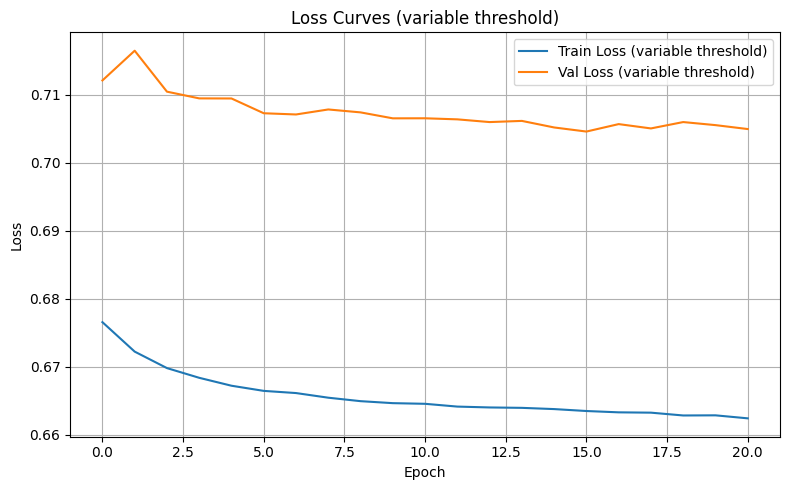

In [ ]:

# Plot loss curves
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
#fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# ax = axes[0]

# ax.plot(train_loss1, label='Train')
# ax.plot(val_loss1, label='Validation ')
# ax.set_ylim([0.6, 0.7])
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Regression loss (weighted Huber)')
# ax.set_title('LSTM baseline - training loss')
# best_epoch = np.argmin(val_loss1)
# ax.axvline(x=best_epoch, color='grey', linestyle='--', label='Best iteration')
# ax.legend()
# ax.grid(True)

axes.plot(train_loss2, label='Train Loss (variable threshold)')
axes.plot(val_loss2, label='Val Loss (variable threshold)')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.set_title('Loss Curves (variable threshold)')
axes.legend()
axes.grid(True)

plt.tight_layout()
plt.savefig('loss_curves.pdf', dpi=300)
plt.show()


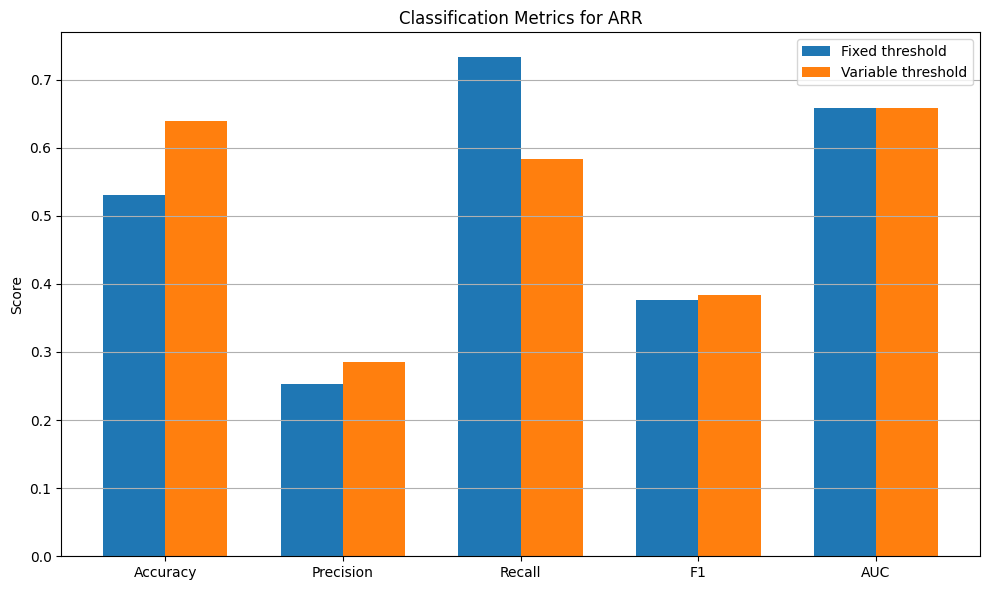

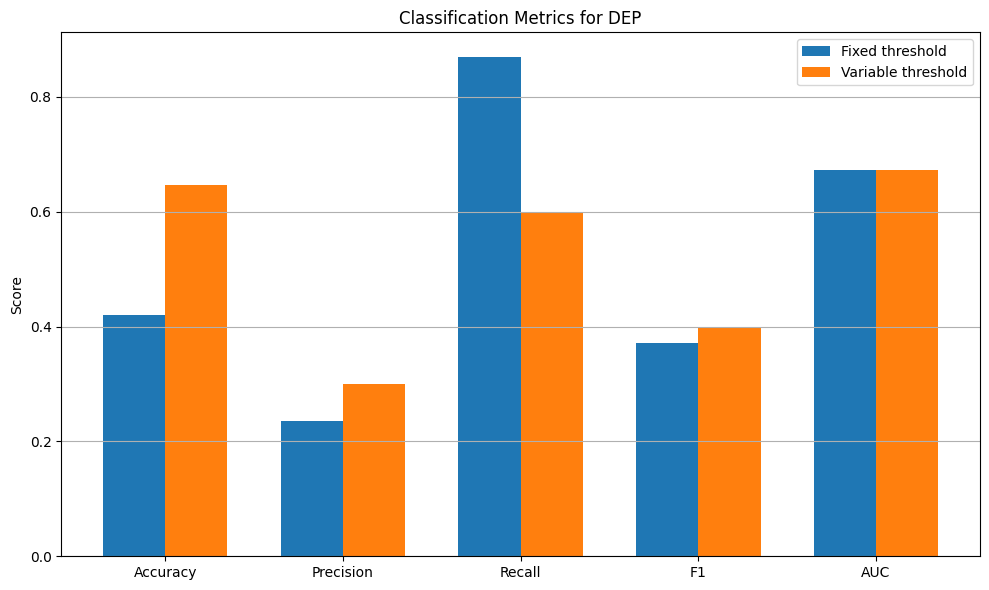

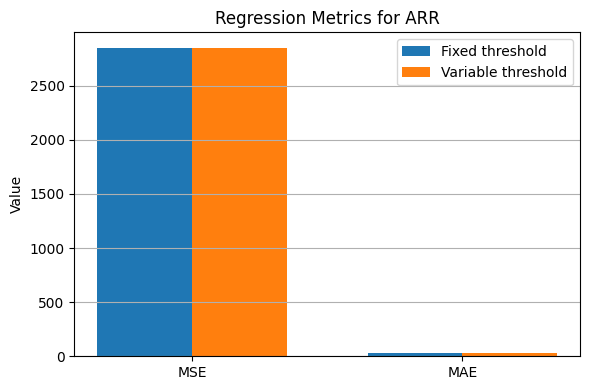

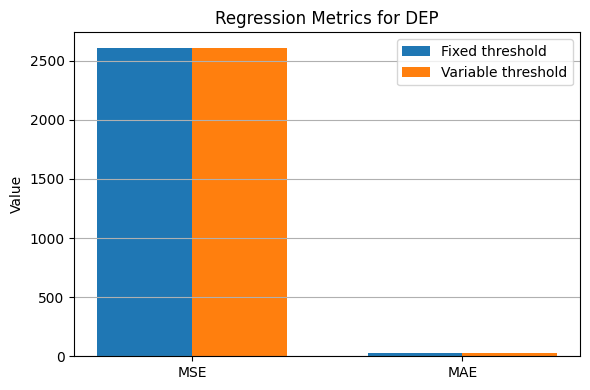

In [ ]:

# Plot classification metrics as bar charts for both thresholds
metrics_list = [metrics1, metrics2]
labels = ['Fixed threshold', 'Variable threshold']
targets = ['arr', 'dep']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

for target in targets:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(metrics_names))
    width = 0.35
    for i, (m, lbl) in enumerate(zip(metrics_list, labels)):
        vals = [m[f'{target}_clf'][name] for name in metrics_names]
        ax.bar(x + i*width, vals, width, label=lbl)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(metrics_names)
    ax.set_ylabel('Score')
    ax.set_title(f'Classification Metrics for {target.upper()}')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(f'metrics_{target}.pdf', dpi=300)
    plt.show()

# Regression metrics (MSE, MAE) as bar charts
for target in targets:
    fig, ax = plt.subplots(figsize=(6, 4))
    reg_keys = ['MSE', 'MAE']
    x = np.arange(len(reg_keys))
    width = 0.35
    for i, (m, lbl) in enumerate(zip(metrics_list, labels)):
        vals = [m[f'{target}_reg'][key] for key in reg_keys]
        ax.bar(x + i*width, vals, width, label=lbl)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(reg_keys)
    ax.set_ylabel('Value')
    ax.set_title(f'Regression Metrics for {target.upper()}')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(f'regression_{target}.pdf', dpi=300)
    plt.show()

In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION METRICS")
print("="*60)
for target in targets:
    print(f"\n{target.upper()} Classification Metrics:")
    print(f"{'Metric':>10} | {'Fixed threshold':>15} | {'Variable threshold':>15}")
    print("-"*50)
    for name in metrics_names:
        val1 = metrics1[f'{target}_clf'][name]
        val2 = metrics2[f'{target}_clf'][name]
        print(f"{name:>10} | {val1:>15.4f} | {val2:>15.4f}")

print("\n" + "="*60)
print("REGRESSION METRICS")
print("="*60)
for target in targets:
    print(f"\n{target.upper()} Regression Metrics:")
    print(f"{'Metric':>10} | {'Fixed threshold':>15} | {'Variable threshold':>15}")
    print("-"*50)
    for key in ['MSE', 'MAE']:
        val1 = metrics1[f'{target}_reg'][key]
        val2 = metrics2[f'{target}_reg'][key]
        print(f"{key:>10} | {val1:>15.4f} | {val2:>15.4f}")


CLASSIFICATION METRICS

ARR Classification Metrics:
    Metric | Fixed threshold | Variable threshold
--------------------------------------------------
  Accuracy |          0.5305 |          0.6384
 Precision |          0.2525 |          0.2856
    Recall |          0.7326 |          0.5834
        F1 |          0.3756 |          0.3834
       AUC |          0.6582 |          0.6582

DEP Classification Metrics:
    Metric | Fixed threshold | Variable threshold
--------------------------------------------------
  Accuracy |          0.4197 |          0.6460
 Precision |          0.2355 |          0.3000
    Recall |          0.8689 |          0.6003
        F1 |          0.3706 |          0.4000
       AUC |          0.6724 |          0.6724

REGRESSION METRICS

ARR Regression Metrics:
    Metric | Fixed threshold | Variable threshold
--------------------------------------------------
       MSE |       2851.0742 |       2851.0742
       MAE |         31.2908 |         31.2908

DEP R